## Bibliotecas

In [2]:
# Bibliotecas
import os
from PIL import Image
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

from funcs import modificacoes1, banco, tvt, modificacoes2
from redes.unet import unet 
from redes.unet_fuzzy import  unet_fuzzy

from redes.fuzzy_layer import (
    FuzzyBottleneckModule,
    FuzzificationLayer,
    FuzzyInferenceLayer,
    DefuzzificationLayer,
)


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, dtype=np.float32)

In [3]:
# Configuração (GPU / mixed precision / strategy)

print('TensorFlow:', tf.__version__)
print('Built with CUDA:', tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print('GPUs:', gpus)
print('CPUs:', cpus)

# Importante: fazer isso ANTES de criar modelos/estratégias, para evitar reservar toda a VRAM
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print('Não foi possível habilitar memory growth:', e)

    # Mixed precision costuma reduzir MUITO o uso de VRAM em U-Net
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', mixed_precision.global_policy())

# Estratégia: só use MirroredStrategy se tiver >1 GPU
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print('Strategy:', type(strategy).__name__)

TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Strategy: _DefaultDistributionStrategy


## Banco de Dados

In [ ]:
path_x_train = 'banco2/teste/femeas_Nelore_e_Caracu/AOLandEGL/imgs'
path_y_train = ['banco2/teste/femeas_Nelore_e_Caracu/AOLandEGL/labels1',
                'banco2/teste/femeas_Nelore_e_Caracu/AOLandEGL/labels2']

# Indexar as máscaras pelo prefixo (ex: "I-2452")
def build_index(mask_dir):
    index = {}
    for fname in os.listdir(mask_dir):
        prefix = fname.split('-')[0] + '-' + fname.split('-')[1]  # "I-2452"
        index[prefix] = fname
    return index

mask_indices = [build_index(d) for d in path_y_train]

X, Y = [], []
for img_name in sorted(os.listdir(path_x_train)):
    prefix = img_name.split('-')[0] + '-' + img_name.split('-')[1]  # "I-2452"

    img = cv2.imread(os.path.join(path_x_train, img_name), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    img = np.expand_dims(img, axis=-1)
    X.append(img)

    channels = []
    for mask_dir, idx in zip(path_y_train, mask_indices):
        mask_name = idx[prefix]
        m = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (256, 256))
        m = (m > 127).astype(np.float32)
        channels.append(m)

    mask_combined = np.stack(channels, axis=-1)
    Y.append(mask_combined)

X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)

(29, 256, 256, 1) (29, 256, 256, 2)


In [33]:
path_x_train = 'banco2/teste/femeas_Nelore_e_Caracu/AOLandEGL/imgs'
path_y_train = 'banco2/teste/femeas_Nelore_e_Caracu/AOLandEGL/labels1'

In [34]:
X, nomes_x_train = banco(path_x_train, resolution=(256,256), grayscale= True, nomes=True)
Y, nones_y_train = banco (path_y_train,resolution=(256,256), grayscale= True, nomes=True)

In [35]:
x_train, y_train, x_test, y_test= tvt(X, Y,shuffle=True, partition=0.8)

In [36]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(23, 256, 256, 1)
(23, 256, 256, 1)
(6, 256, 256, 1)
(6, 256, 256, 1)


In [37]:
dict_x_train, x_train_m = modificacoes1(x_train, 
             sorted(os.listdir(path_x_train)), 
             original = True, 
             brilho = 1.7,
             escura= 0.5)

dict_x_test, x_test_m = modificacoes1(x_test, 
             sorted(os.listdir(path_x_train)), 
             original = True, 
             brilho = 1.7,
             escura= 0.5)

In [38]:
print(len(dict_x_train.keys()))
print(len(dict_x_train.values()))

print(len(dict_x_test.keys()))
print(len(dict_x_test.values()))

69
69
18
18


In [39]:
# Modificando as labels
y_train_m = dict(zip(sorted(os.listdir(path_x_train)), y_train))
y_test_m = dict(zip(sorted(os.listdir(path_x_train)), y_test))
print(f'Quantidade de chaves em y_train: {len(y_train_m)}')    
print(f'Quantidade de chaves em y_train: {len(y_test_m)}')  

Quantidade de chaves em y_train: 23
Quantidade de chaves em y_train: 6


In [40]:
y_train_m, y_train_nomes= modificacoes2(y_train_m, dict_x_train.keys())
y_test_m, y_test_nomes = modificacoes2(y_test_m, dict_x_train.keys())

In [41]:
print(len(y_train_m))
print(len(y_train_nomes))

print(len(y_test_m))
print(len(y_test_nomes))

69
69
18
18


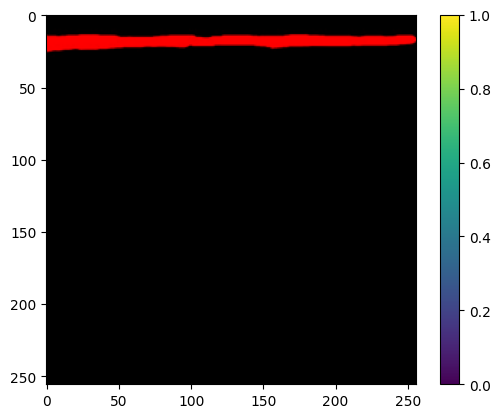

In [42]:
idx = 6
rgb = np.zeros((256,256,3))
rgb[:,:,0] = y_test_m[idx][:,:,0]
# rgb[:,:,1] = y_test_m[idx][:,:,1]
plt.imshow(rgb)
plt.colorbar()
plt.show()

In [43]:
x_train_m = np.array(x_train_m)
y_train_m = np.array(y_train_m)

x_test_m = np.array(x_test_m)
y_test_m = np.array(y_test_m)

In [44]:
print(x_train_m.shape)
print(y_train_m.shape)

print(x_test_m.shape)
print(y_test_m.shape)

(69, 256, 256, 1)
(69, 256, 256, 1)
(18, 256, 256, 1)
(18, 256, 256, 1)


## Funções

In [4]:
# Converting the arrays into tf.data batches (mais leve e eficiente)
import gc
AUTOTUNE = tf.data.AUTOTUNE

# Se ainda der OOM, o 1o ajuste e reduzir batch_size
batch_size = 1

""" setting DICE coefficient to evaluate the model """
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten per-sample to compute Dice over all pixels
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    dice_coeff = (2.0 * intersection + smooth) / (union + smooth)
    return dice_coeff


""" setting DICE loss to train the model"""

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

In [5]:
shuffle_buffer = min(256, len(x_train_m))

# Evita float64 acidental em RAM
x_train_m = x_train_m.astype(np.float32, copy=False)
y_train_m = y_train_m.astype(np.float32, copy=False)

train_data = tf.data.Dataset.from_tensor_slices((x_train_m, y_train_m))
train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

test_data = tf.data.Dataset.from_tensor_slices((x_test_m, y_test_m))
test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)

NameError: name 'x_train_m' is not defined

In [ ]:
""" Unet-Fuzzy com input de classe (multitask) """
input_shape = tuple(x_train_m.shape[1:])

with strategy.scope():
    unetFuzzy = unet_fuzzy(
        n_classes=1,
        input_shape=input_shape,
        base_filters=64,
        max_filters=512,
        use_class_input=None,
        use_fuzzy=True,
        num_fuzzy_sets=3,    # Baixo / Médio / Alto
        num_fuzzy_rules=16,  # 16 regras fuzzy no bottleneck
    )
    unetFuzzy.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient],
    )
unetFuzzy.summary()

Model: "Fuzzy_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 256, 256,  │        640 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 256, 256,  │          0 │ conv2d_57[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 256, 256,  │     36,928 │ dropout_24[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 128, 128,  │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_12… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128, 128,  │          0 │ conv2d_59[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 128, 128,  │    147,584 │ dropout_25[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 64, 64,    │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_13… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 64, 64,    │          0 │ conv2d_61[0][0]   │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 64, 64,    │    590,080 │ dropout_26[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ conv2d_62[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_14… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 32, 32,    │          0 │ conv2d_63[0][0]   │
│ (Dropout)           │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ dropout_27[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 16, 16,    │          0 │ conv2d_64[0][0] 

 Total params: 27,625,793 (105.38 MB)

 Trainable params: 27,623,745 (105.38 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
""" Defining early stopping callback """
early_stopping = EarlyStopping(monitor='val_dice_coefficient', patience=15, restore_best_weights=True, mode='max')

## Treino

In [49]:
""" Treinando UnetFuzzy """
unetFuzzy_history = unetFuzzy.fit(
    train_data,
    validation_data=test_data,
    epochs=200,
    callbacks=[early_stopping]
)

unetFuzzy.save('modelos/unetFuzzyEGG2_model.keras')

Epoch 1/200


I0000 00:00:1775134160.674024   24958 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_58456__.144


69/69 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.9204 - dice_coefficient: 0.0423 - loss: 0.3216 - val_accuracy: 0.9654 - val_dice_coefficient: 0.0490 - val_loss: 0.1099
Epoch 2/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9660 - dice_coefficient: 0.3183 - loss: 0.0415 - val_accuracy: 0.9654 - val_dice_coefficient: 0.0219 - val_loss: 0.1217
Epoch 3/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9660 - dice_coefficient: 0.4468 - loss: 0.0320 - val_accuracy: 0.9654 - val_dice_coefficient: 0.3970 - val_loss: 0.0374
Epoch 4/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9665 - dice_coefficient: 0.4878 - loss: 0.0288 - val_accuracy: 0.9657 - val_dice_coefficient: 0.3807 - val_loss: 0.0407
Epoch 5/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9717 - dice_coefficient: 0.6170 - loss: 0.0242 - val_accuracy: 0.9704 - val_dice_coefficient: 0.5094 - val_loss: 0.0379
Epoch 6/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9726 - dice_co

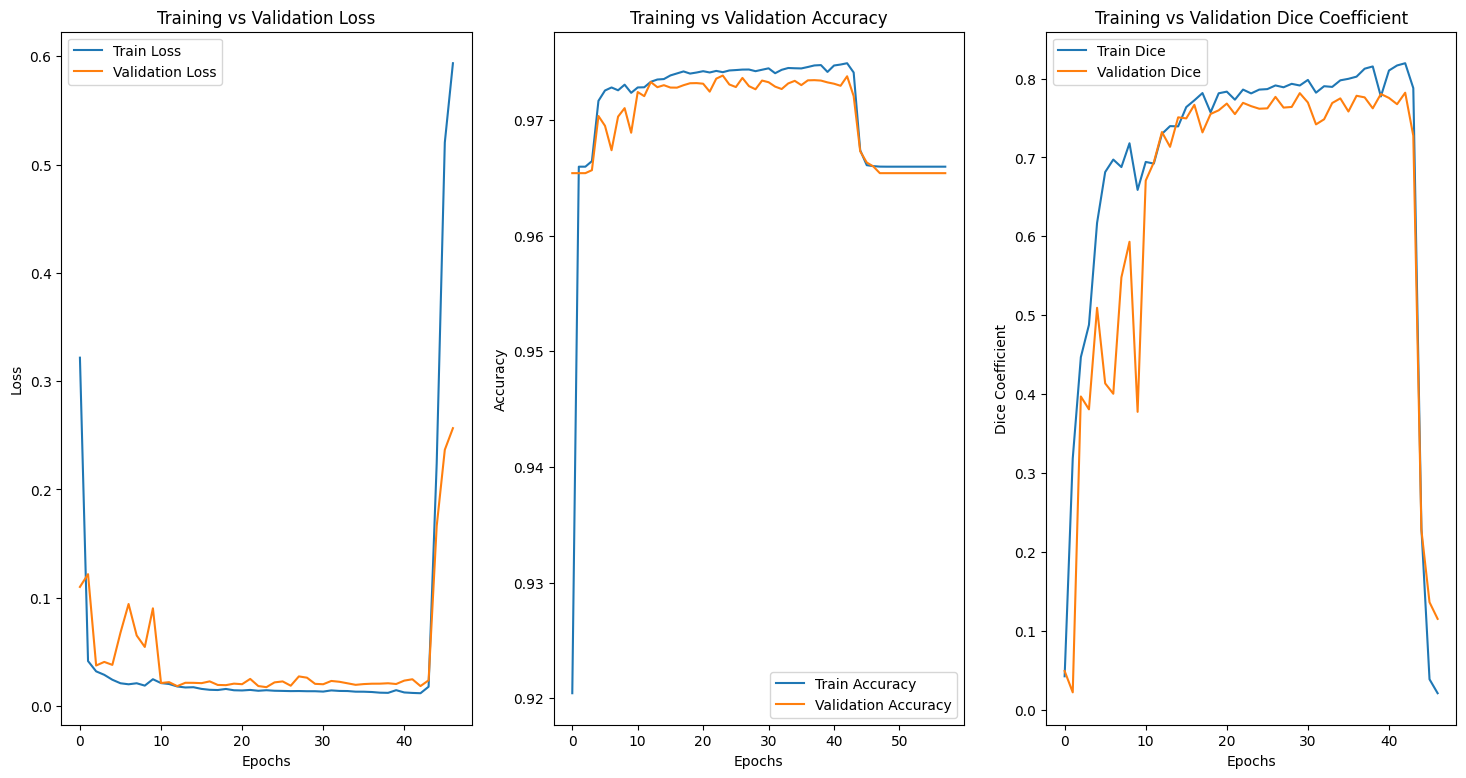

In [50]:
""" plotting the loss and accuracy during training and validation """
plt.figure(figsize=(18, 9))
plt.subplot(1, 3, 1)
plt.plot(unetFuzzy_history.history['loss'])
plt.plot(unetFuzzy_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.subplot(1, 3, 2)
plt.plot(unetFuzzy_history.history['accuracy'])
plt.plot(unetFuzzy_history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.subplot(1, 3, 3)
plt.plot(unetFuzzy_history.history['dice_coefficient'])
plt.plot(unetFuzzy_history.history['val_dice_coefficient'])
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Training vs Validation Dice Coefficient')
plt.legend(['Train Dice', 'Validation Dice'])


## Teste

In [ ]:
modelo1 = keras.models.load_model('modelos/unetFuzzyEGG2_model.keras', custom_objects={'dice_coefficient': dice_coefficient, 'dice_loss': dice_loss}) # expessura de gordura
modelo2 = keras.models.load_model('modelos/unetFuzzyEGG_model.keras', custom_objects={'dice_coefficient': dice_coefficient, 'dice_loss': dice_loss})  # Ponta da picanha

I0000 00:00:1775168684.513098    5925 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [ ]:
modelo1.evaluate(test_data, verbose=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9738 - dice_coefficient: 0.7820 - loss: 0.0184


[0.018374480307102203, 0.9737972617149353, 0.7820349335670471]

In [134]:
matrix1 = np.array([[1,1,1],[0,1,0],[0,1,0]])
matrix2 = np.array([[0,0,0],[0,1,0],[0,1,0]])

In [128]:
# Função para calcular a altura na interseção das imagens
def altura(mask1: np.ndarray, mask2: np.ndarray ) -> float:
    rows, cols = mask1.shape 
    
    h_intersect = 0
    cont = 0 
    for col in range(cols):
        fist_col_mask1 = 0
        hight = 0
        for row in range(rows):
            if mask1[row, col] == 1:
                cont +=1
                if row == len(mask1) -1:
                    hight = cont
            else:
                if cont != 0:
                    hight = cont
                    cont = 0
            if mask2[row, col] == 1 and fist_col_mask1 == 0:
                if hight != 0 and hight >= cont:
                    fist_col_mask1 = [col, row]
                    h_intersect = hight
    return h_intersect


In [135]:
h = altura(matrix1, matrix2)
print(h)

3


A expessura da gordura é: 0.00cm


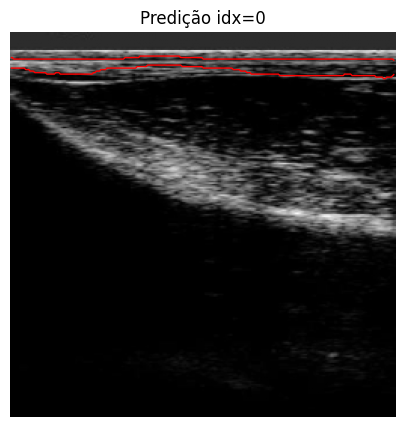

A expessura da gordura é: 0.00cm


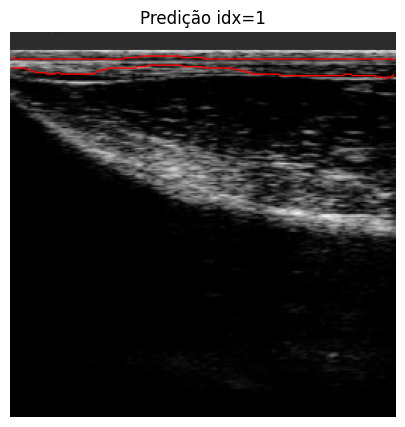

A expessura da gordura é: 0.25cm


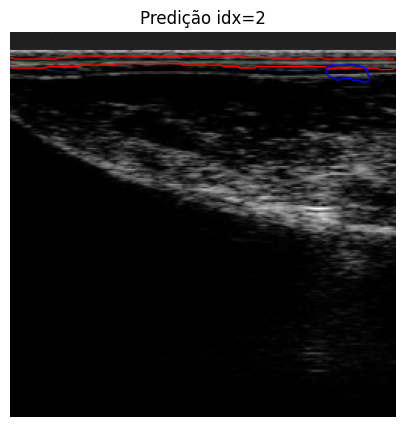

A expessura da gordura é: 0.25cm


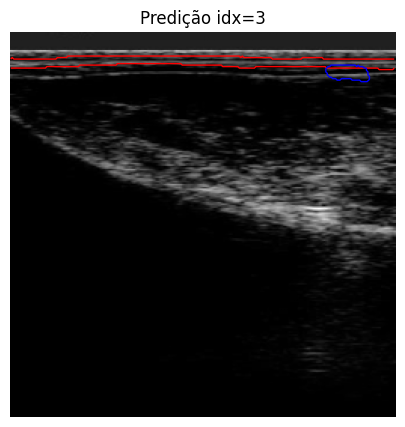

A expessura da gordura é: 0.21cm


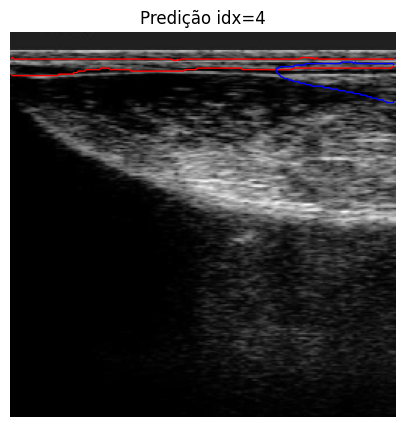

A expessura da gordura é: 0.21cm


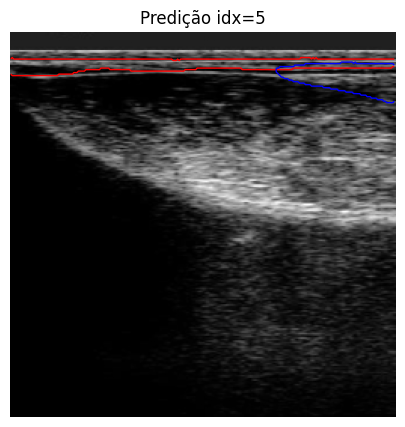

A expessura da gordura é: 0.29cm


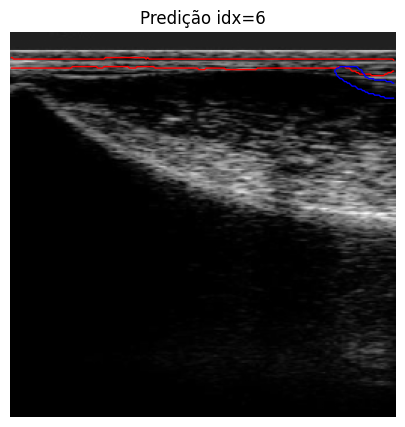

A expessura da gordura é: 0.29cm


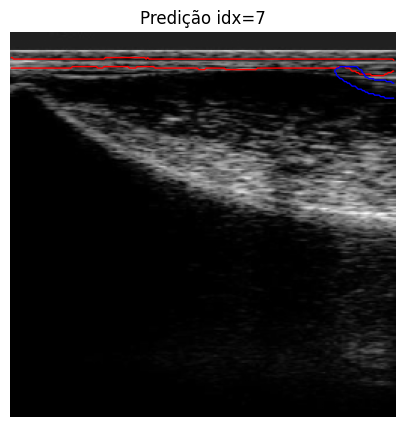

A expessura da gordura é: 0.21cm


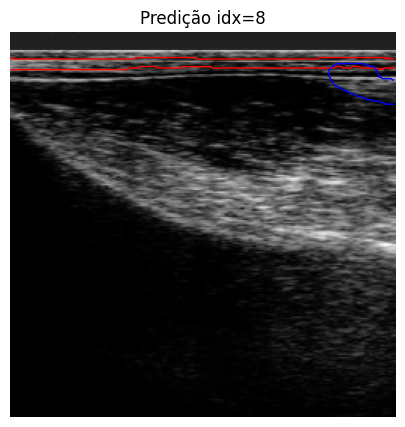

A expessura da gordura é: 0.21cm


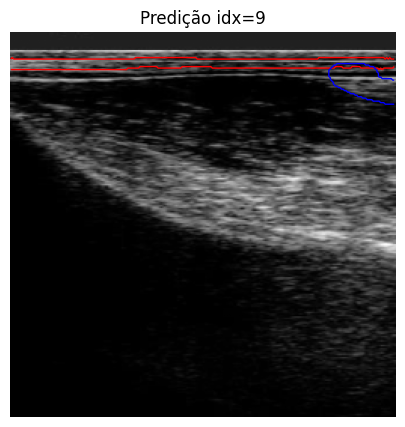

In [137]:
x_teste = '/home/victors/Documents/Codigos_Mestrado/banco2/teste/EGG_US_FEMEAS_NELORE_MANHA_07052024/imgs'
x_teste, nomes_x_teste = banco(x_teste, resolution=(256,256), grayscale= True, nomes= True)
threshold = 0.5
class_teste = np.array([[0,1] if nome[2:3] == '6' else [1,0] for nome in nomes_x_teste])
for i in range(len(x_teste[:10])):
    y1 = modelo1.predict(tf.expand_dims(x_teste[i], axis=0), verbose=0)
    y1 = (y1 > threshold).astype(np.float32)

    y2 = modelo2.predict(tf.expand_dims(x_teste[i], axis=0), verbose=0)
    y2 = (y2 > threshold).astype(np.float32)

    
    h_y1 = np.squeeze(y1)
    h_y2 = np.squeeze(y2)
    
    hight = altura(h_y1,h_y2)
    cmpx = 1/24.05
    hight = hight*cmpx
    print(f"A expessura da gordura é: {hight:.2f}cm")
    img = np.squeeze(x_teste[i])
    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap='gray')
    # plt.imshow(np.squeeze(y), cmap='Blues', alpha=0.35, vmin=0, vmax=1)
    plt.contour(h_y1, levels=[0.5], colors='red', linewidths=1)
    plt.contour(h_y2, levels=[0.5], colors='blue', linewidths=1)
    plt.title(f'Imagem idx={i} | {nomes_x_teste[i][2:6]}')
    plt.axis('off')
    plt.title(f'Predição idx={i}')
    plt.axis('off')
    plt.show()